In [1]:
import os
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
os.chdir("E:/PHD/PHD_main/Projects/Precipitation-performance")

# os.chdir('/media/jopato/jopato_ssd/PHD/PHD_main/Projects/Precipitation-performance')

## Load Data

In [2]:
# Load pickle with processed data
with open("export_results/generator_export.pkl", "rb") as f:
    processed_data = pickle.load(f)

In [3]:
# Read all data
df_all = pd.read_csv('export_results/all_processed_data.csv')

In [4]:
# Rename dataset name for paper
replace_dict = {
    'data':'Local',
    'rawGPM': 'GPM-IMERGF',
    'gwrGPM': 'GPM-GWR',
    'PISCO': 'PISCO',
    'rain4pe': 'Rain4PE',
    'expGPM': 'GPM-EXP'
}

df_all['Dataset'] = df_all['Dataset'].replace(replace_dict)

In [5]:
# Filter data per dataset
df_data = df_all[df_all['Dataset']=='Local']

df_rawGPM    = df_all[df_all['Dataset']=='GPM-IMERGF'].reset_index(drop=True)
df_gwrGPM    = df_all[df_all['Dataset']=='GPM-GWR'].reset_index(drop=True)
df_PISCO     = df_all[df_all['Dataset']=='PISCO'].reset_index(drop=True)
df_rain4pe   = df_all[df_all['Dataset']=='Rain4PE'].reset_index(drop=True)
df_expGPM    = df_all[df_all['Dataset']=='GPM-EXP'].reset_index(drop=True)

## Precipitation Plots

C:\Users\joset\AppData\Local\Temp\ipykernel_30716\3546959893.py:8: UserWarning: The palette list has more values (13) than needed (6), which may not be intended.
  sns.violinplot( x='Dataset', y='Precipitation', data=df_all, inner='box',


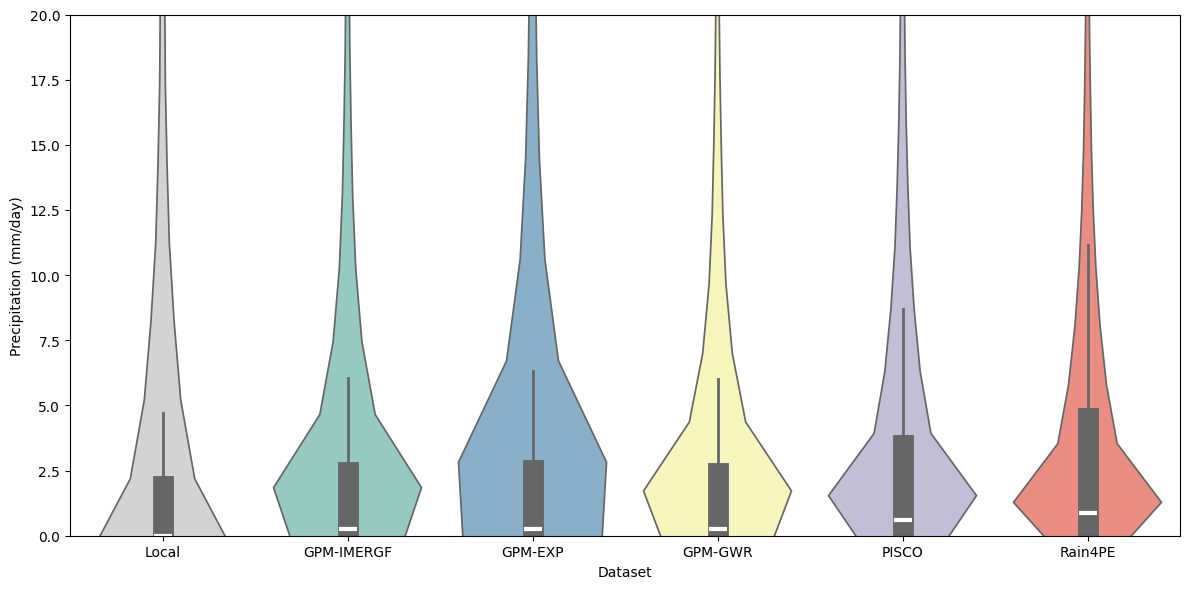

In [6]:
# Print precipitation distribution - absolute values
order_list = ["Local","GPM-IMERGF", "GPM-EXP", "GPM-GWR", "PISCO", "Rain4PE"]
set2_colors = sns.color_palette("Set3")
custom_palette = ["lightgrey"] + list(set2_colors)

plt.figure(figsize=(12, 6))

sns.violinplot( x='Dataset', y='Precipitation', data=df_all, inner='box',
                hue='Dataset', palette=custom_palette, 
                legend=False,order=order_list,native_scale=True,
                inner_kws=dict(box_width=15, whis_width=2, color=".4"))

# plt.title('Daily Precipitation Distribution by Dataset')
plt.ylabel('Precipitation (mm/day)')
plt.xlabel('Dataset')
plt.ylim([0,20])
plt.grid(False)
plt.tight_layout()
plt.show()

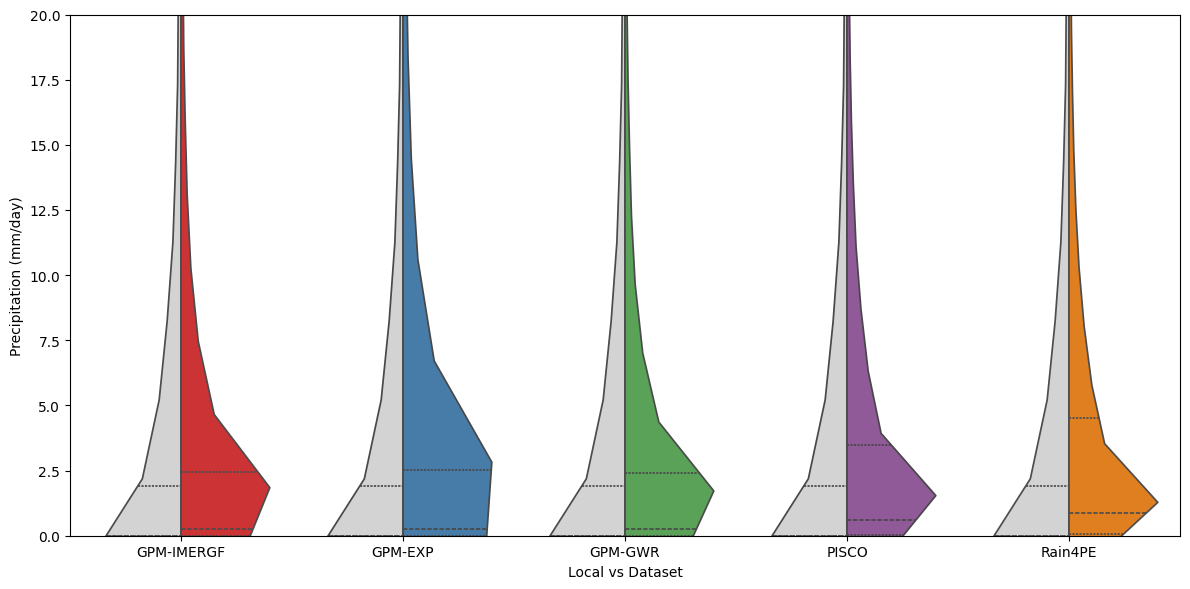

In [7]:
# Plot comparioson of violin plots
order_list = ["Local","GPM-IMERGF","GPM-EXP","GPM-GWR","PISCO","Rain4PE"]
non_local = order_list[1:]

# Get Local values once
local_vals = df_all.loc[df_all["Dataset"]=="Local", "Precipitation"]

# Build comparison DataFrame
parts = []
for d in non_local:
    d_vals = df_all.loc[df_all["Dataset"]==d, "Precipitation"]
    parts.append(pd.DataFrame({"Group": d, "Source": "Local",   "Precipitation": local_vals.values}))
    parts.append(pd.DataFrame({"Group": d, "Source": "Dataset", "Precipitation": d_vals.values}))
df_plot = pd.concat(parts, ignore_index=True)

# Colors
set3 = sns.color_palette("Set1")

plt.figure(figsize=(12,6))

# Plot each dataset separately for per-dataset coloring
for i, d in enumerate(non_local):
    sub = df_plot[df_plot["Group"]==d]
    pal = {"Local": "lightgrey", "Dataset": set3[i % len(set3)]}
    sns.violinplot(
        data=sub, x="Group", y="Precipitation", hue="Source",
        split=True, inner="quart", palette=pal, order=[d],
        # Key bits to resemble your original:
        density_norm="area",      # like old default "scale='area'"
        common_norm=False,        # don't normalize across groups
        cut=2,                    # keep KDE tails (like seaborn default)
        bw_adjust=1,              # match default bandwidth
        native_scale=True,

    )

plt.ylabel("Precipitation (mm/day)")
plt.xlabel("Local vs Dataset")
plt.ylim(0, 20)
plt.legend([], [], frameon=False)  # Remove duplicate legends
plt.tight_layout()

## Performance Statistics

In [8]:
def get_statistics(stat_name):
    # Create a list to hold all the data
    all_stats = []
    # Define your datasets and their corresponding stats dictionaries
    dataset_stats = {
        'GPM-IMERGF':   processed_data.statsrawGPM_dict,
        'GPM-GWR':   processed_data.statsgwrGPM_dict,
        'PISCO':    processed_data.statsPISCO_dict,
        'Rain4PE':  processed_data.statsrain4pe_dict,
        'GPM-EXP':   processed_data.statsexpGPM_dict
    }

    # Loop through each dataset and each station
    for dataset_name, stats_dict in dataset_stats.items():
        for station_name, stats_obj in stats_dict.items():
            # Get the desired stat from the stats object
            value = getattr(stats_obj,stat_name)
            if value is not None:
                all_stats.append({
                    'Station': station_name,
                    'Dataset': dataset_name,
                    'Statistic': float(value)
                })

    # Convert to DataFrame
    df = pd.DataFrame(all_stats)

    return df

In [9]:
df_pbias    = get_statistics('pbias')
df_rmse     = get_statistics('rmse')
df_kge      = get_statistics('kge')
df_r        = get_statistics('r')

df_acc      = get_statistics('acc')
df_pod      = get_statistics('pod')
df_far      = get_statistics('far')
df_fbi      = get_statistics('fbi')

In [11]:
stat_df_dict = {
    'pbias': df_pbias,
    'rmse' : df_rmse,
    'kge'  : df_kge,
    'r'    : df_r,
}

### Distribution Plot

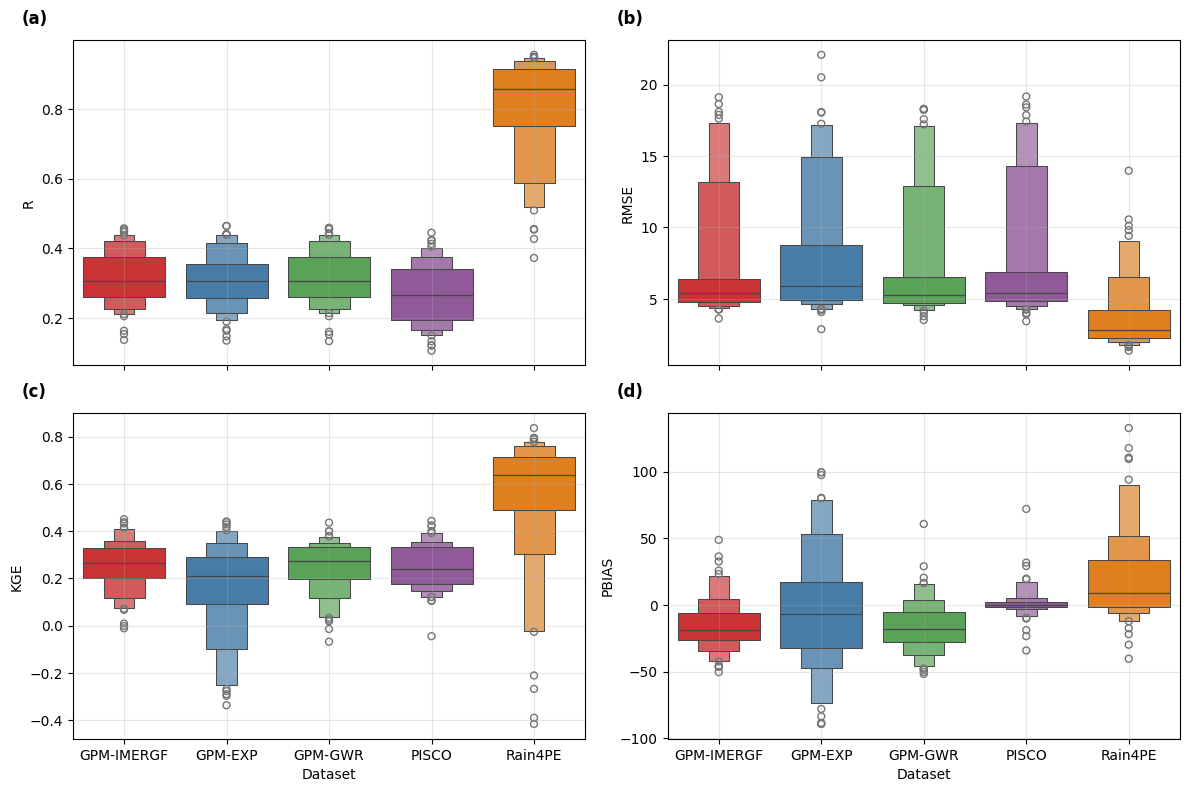

In [10]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
order_list = ["GPM-IMERGF","GPM-EXP","GPM-GWR","PISCO","Rain4PE"]
stat_names = ['r', 'rmse', 'kge', 'pbias']
df_dict = {
    'pbias': df_pbias,
    'rmse' : df_rmse,
    'kge'  : df_kge,
    'r'    : df_r,
}

panel_labels = ['(a)', '(b)', '(c)', '(d)']
axes = axs.ravel()

for i, stat_name in enumerate(stat_names):
    ax = axes[i]
    sns.boxenplot(
        x='Dataset', y='Statistic', hue='Dataset',
        data=df_dict[stat_name], palette='Set1',
        order=order_list, ax=ax, hue_order=order_list,
    )
    ax.set_xlabel('Dataset')
    ax.set_ylabel(stat_name.upper())
    ax.grid(True, alpha=0.3)
    # Add panel label
    ax.text(-0.1, 1.05, panel_labels[i],
            transform=ax.transAxes, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### Spatial Plot

In [23]:
# Read stations
station_shp = 'gis/selected_stations_slope.gpkg'
stations_gdf = gpd.read_file(station_shp).rename(columns = {"Name": "Station","study_area_1km_res": "Elevation"})
station_df  = stations_gdf.copy()[['Station','Elevation','Slope']]


In [24]:
stations_gdf

,Station,Elevation,Slope,geometry
0,Crisnejas_ Augusto Weberbauer,2686.0,3.37635,POINT (-8738580.027 -794551.22)
1,Crisnejas_ Cachachi,3335.0,19.27959,POINT (-8712830.716 -826245.905)
2,Crisnejas_ Cajabamba,2609.0,4.61169,POINT (-8688609.821 -845290.164)
3,Crisnejas_ Huamachuco,3204.0,8.99701,POINT (-8687373.062 -867343.416)
4,Crisnejas_ Huangacocha,3805.0,8.57343,POINT (-8690501.139 -880554.012)
...,...,...,...,...
65,Perene_ Ricran,4254.0,15.30470,POINT (-8408250.57 -1286670.858)
66,Perene_ Runatullo,3707.0,24.76914,POINT (-8354616.84 -1290848.157)
67,Perene_ Satipo,576.0,4.57337,POINT (-8305391.361 -1249256.814)
68,Perene_ Satipo2,576.0,4.57337,POINT (-8305391.361 -1249256.814)


In [28]:
# Do spatial plot
statistics = ['pbias', 'rmse', 'kge', 'r']
datasets   = ['GPM-IMERGF', 'GPM-GWR', 'PISCO', 'Rain4PE', 'GPM-EXP']

spatial_plot_dict = {}

for ds in datasets:
    df_ds = stations_gdf.copy()  # start with stations (keeps geometry)
    for stat in statistics:
        # keep only Station and the renamed stat column for this dataset
        tmp = (stat_df_dict[stat]
               .rename(columns={'Statistic': stat})
               .loc[lambda d: d['Dataset'] == ds, ['Station', stat]]
               .reset_index(drop=True))
        df_ds = df_ds.merge(tmp, on='Station', how='left')
    spatial_plot_dict[ds] = df_ds

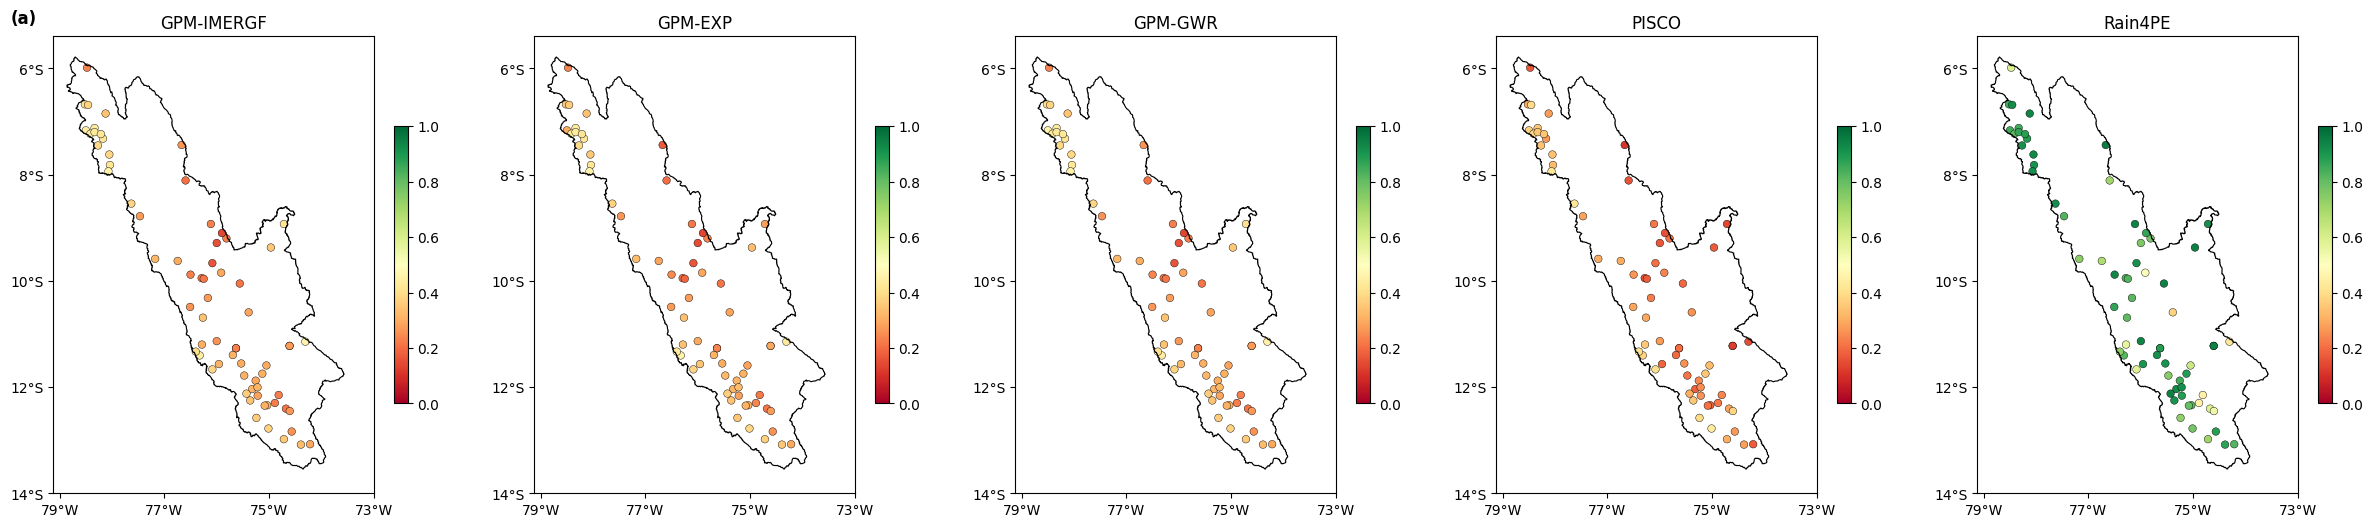

In [81]:
# Spatial plot for one statistic
area_study_shape = gpd.read_file('gis/study_area_shp/study_area.shp')
statistic = 'r'
datasets   = ['GPM-IMERGF', 'GPM-EXP','GPM-GWR', 'PISCO', 'Rain4PE']

fig, axs = plt.subplots(1, 5, figsize = (30,6), subplot_kw={'aspect': 'equal'})

axs = axs.ravel()


for i, ds in enumerate(datasets):
    ax = axs[i]
    if i == 0:
        ax.text(
        -0.05, 1.02, '(a)',
        transform=ax.transAxes,
        fontsize=12,
        fontweight='bold',
        va='bottom',
        ha='right'
        )
    df_ds = spatial_plot_dict[ds].to_crs(epsg=4326)  # Ensure CRS is WGS84 for plotting
    if statistic == 'pbias':
        # Convert to absolute values
        df_ds[statistic] = df_ds[statistic].abs()
    
    
    df_ds.plot(column=statistic, ax=ax, legend=True, cmap='RdYlGn', 
               markersize=30,legend_kwds={'shrink':0.6}, vmin = 0 , vmax = 1 , alpha = 1.0,
                edgecolor='black', linewidth=0.3)
    
    ax.set_title(f"{ds}")
    area_study_shape.to_crs(epsg=4326).plot(ax=ax, color='none', edgecolor='black', linewidth=0.8)

    # Set custom tick spacing
    xtick_step = 2  # longitude spacing
    ytick_step = 2  # latitude spacing
    
    xmin, xmax = -79, -73
    ymin, ymax = -14 , -5
    xticks = np.arange(np.floor(xmin), np.ceil(xmax) + 1, xtick_step)
    yticks = np.arange(np.floor(ymin), np.ceil(ymax) + 1, ytick_step)

    ax.set_xticks(xticks)
    ax.set_yticks(yticks)
    
    # Optional: add degree symbol formatting
    ax.set_xticklabels([f"{abs(x):.0f}°{'W' if x < 0 else 'E'}" for x in xticks])
    ax.set_yticklabels([f"{abs(y):.0f}°{'S' if y < 0 else 'N'}" for y in yticks])
    

    # ax.set_xlabel('Longitude')
    # ax.set_ylabel('Latitude')
    


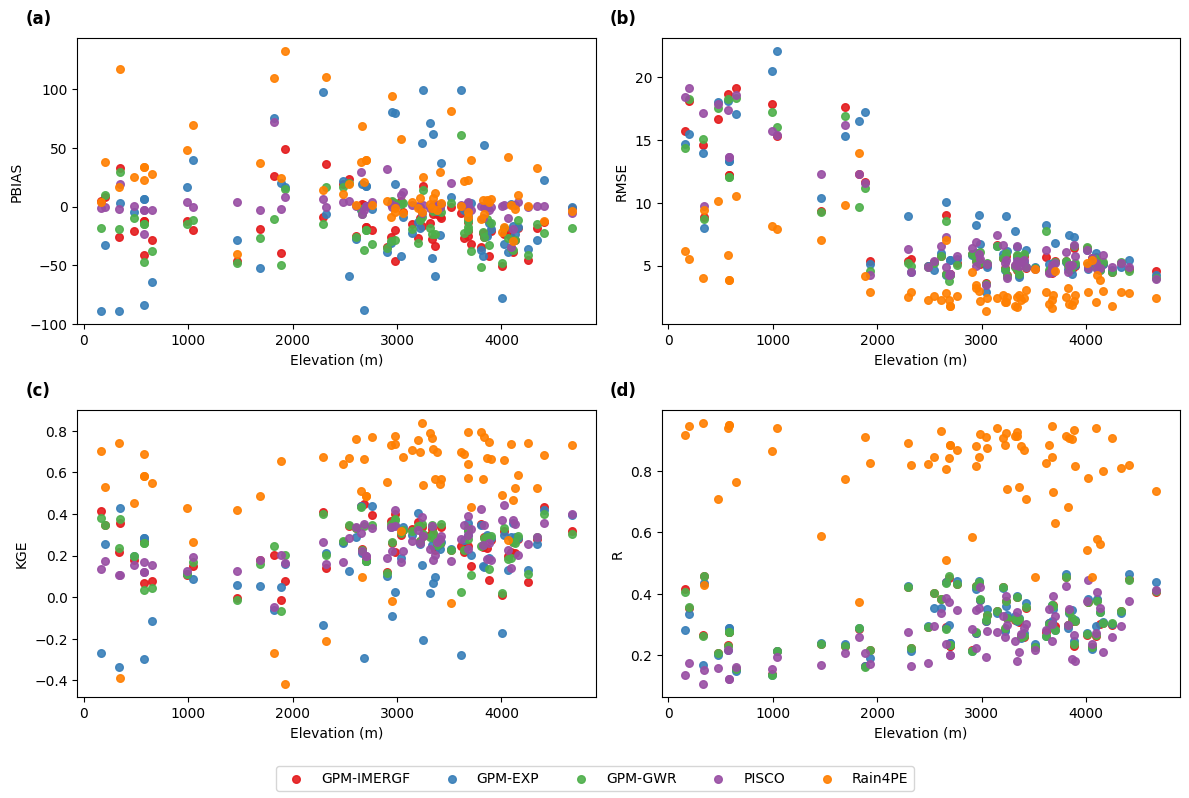

In [82]:
# Do comparison plot of statistic vs elevation per dataset
stats = ['pbias', 'rmse', 'kge', 'r']
order_list = ["GPM-IMERGF","GPM-EXP","GPM-GWR","PISCO","Rain4PE"]

palette = sns.color_palette("Set1", n_colors=len(order_list))
color_map = dict(zip(order_list, palette))

panel_labels = ['(a)', '(b)', '(c)', '(d)']

fig, axs = plt.subplots(2, 2, figsize=(12, 8))

for i, stat in enumerate(stats):
    ax = axs[i // 2, i % 2]
    df_stat = df_dict[stat].copy()
    df_stat = df_stat.merge(station_df, on='Station', how='left')
    
    for ds in order_list:
        sub = df_stat[df_stat['Dataset'] == ds]
        ax.scatter(sub['Elevation'], sub['Statistic'], s=30, alpha=0.9, label=ds, color=color_map[ds])
    
    ax.set_xlabel('Elevation (m)')
    ax.set_ylabel(stat.upper())
    ax.text(-0.1, 1.05, panel_labels[i],
            transform=ax.transAxes, fontsize=12, fontweight='bold')
fig.legend(order_list, loc="lower center", ncol=len(order_list), frameon=True)
plt.tight_layout(rect=[0, 0.05, 1, 1])

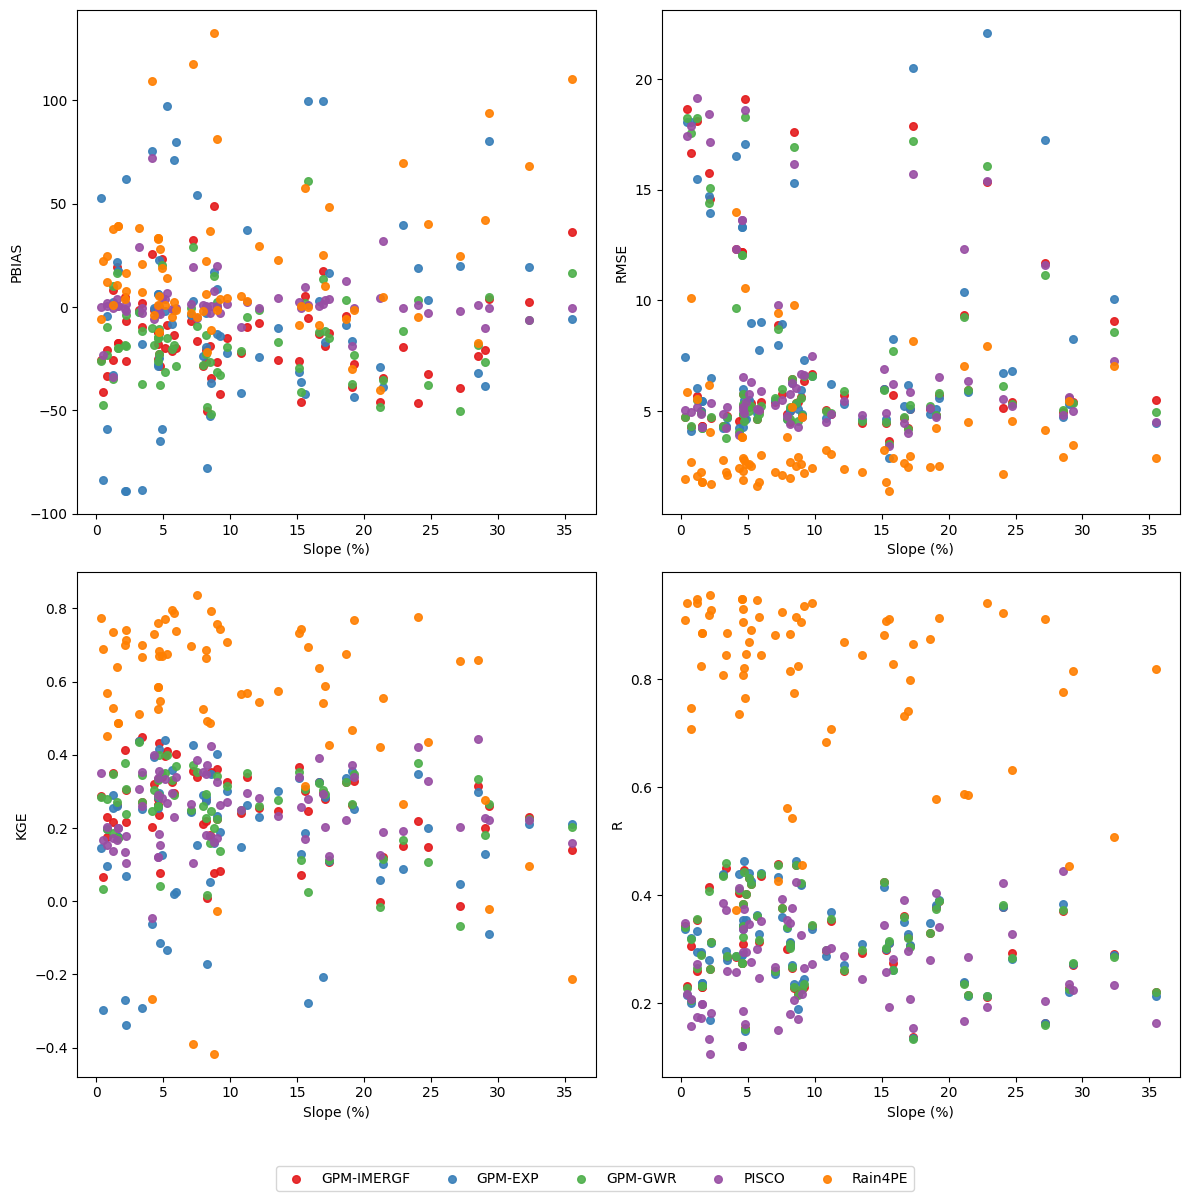

In [83]:
# Do comparison plot of statistic vs elevation per dataset
stats = ['pbias', 'rmse', 'kge', 'r']
order_list = ["GPM-IMERGF","GPM-EXP","GPM-GWR","PISCO","Rain4PE"]

palette = sns.color_palette("Set1", n_colors=len(order_list))
color_map = dict(zip(order_list, palette))



fig, axs = plt.subplots(2, 2, figsize=(12, 12))

for i, stat in enumerate(stats):
    ax = axs[i // 2, i % 2]
    df_stat = df_dict[stat].copy()
    df_stat = df_stat.merge(station_df, on='Station', how='left')
    
    for ds in order_list:
        sub = df_stat[df_stat['Dataset'] == ds]
        ax.scatter(sub['Slope'], sub['Statistic'], s=30, alpha=0.9, label=ds, color=color_map[ds])
    
    ax.set_xlabel('Slope (%)')
    ax.set_ylabel(stat.upper())
    
fig.legend(order_list, loc="lower center", ncol=len(order_list), frameon=True)
plt.tight_layout(rect=[0, 0.05, 1, 1])

### Forecasting indices

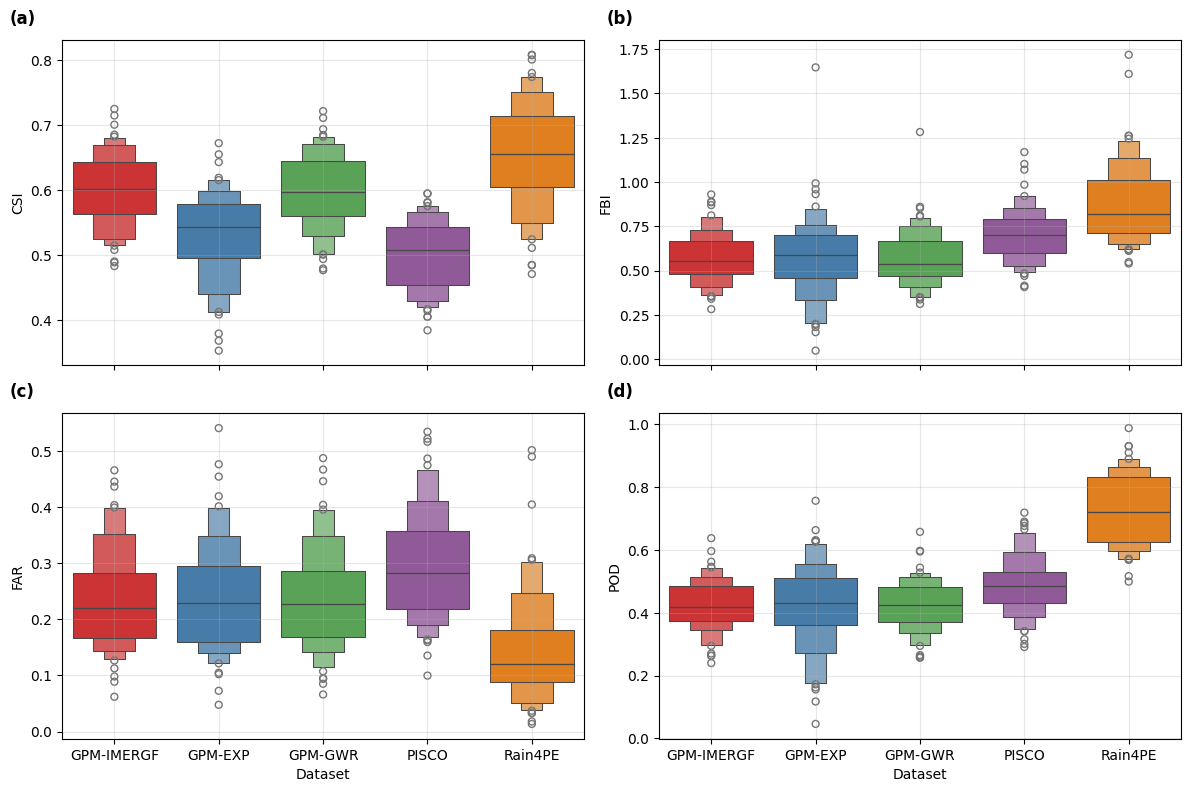

In [86]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
order_list = ["GPM-IMERGF","GPM-EXP","GPM-GWR","PISCO","Rain4PE"]
stat_names = ['csi', 'fbi', 'far', 'pod']
df_dict = {
    'csi'  : df_acc,
    'fbi'  : df_fbi,
    'far'  : df_far,
    'pod'  : df_pod,
}

panel_labels = ['(a)', '(b)', '(c)', '(d)']
axes = axs.ravel()

for i, stat_name in enumerate(stat_names):
    ax = axes[i]
    sns.boxenplot(
        x='Dataset', y='Statistic', hue='Dataset',
        data=df_dict[stat_name], hue_order=order_list, order=order_list, palette='Set1',
        ax=ax
    )
    ax.set_xlabel('Dataset')
    ax.set_ylabel(stat_name.upper())
    ax.grid(True, alpha=0.3)
    # Add panel label
    ax.text(-0.1, 1.05, panel_labels[i],
            transform=ax.transAxes, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [87]:
# Do spatial plot
statistics = ['csi', 'fbi', 'far', 'pod']
datasets   = ['GPM-IMERGF', 'GPM-GWR', 'PISCO', 'Rain4PE', 'GPM-EXP']

spatial_plot_dict = {}

for ds in datasets:
    df_ds = stations_gdf.copy()  # start with stations (keeps geometry)
    for stat in statistics:
        # keep only Station and the renamed stat column for this dataset
        tmp = (df_dict[stat]
               .rename(columns={'Statistic': stat})
               .loc[lambda d: d['Dataset'] == ds, ['Station', stat]]
               .reset_index(drop=True))
        df_ds = df_ds.merge(tmp, on='Station', how='left')
    spatial_plot_dict[ds] = df_ds

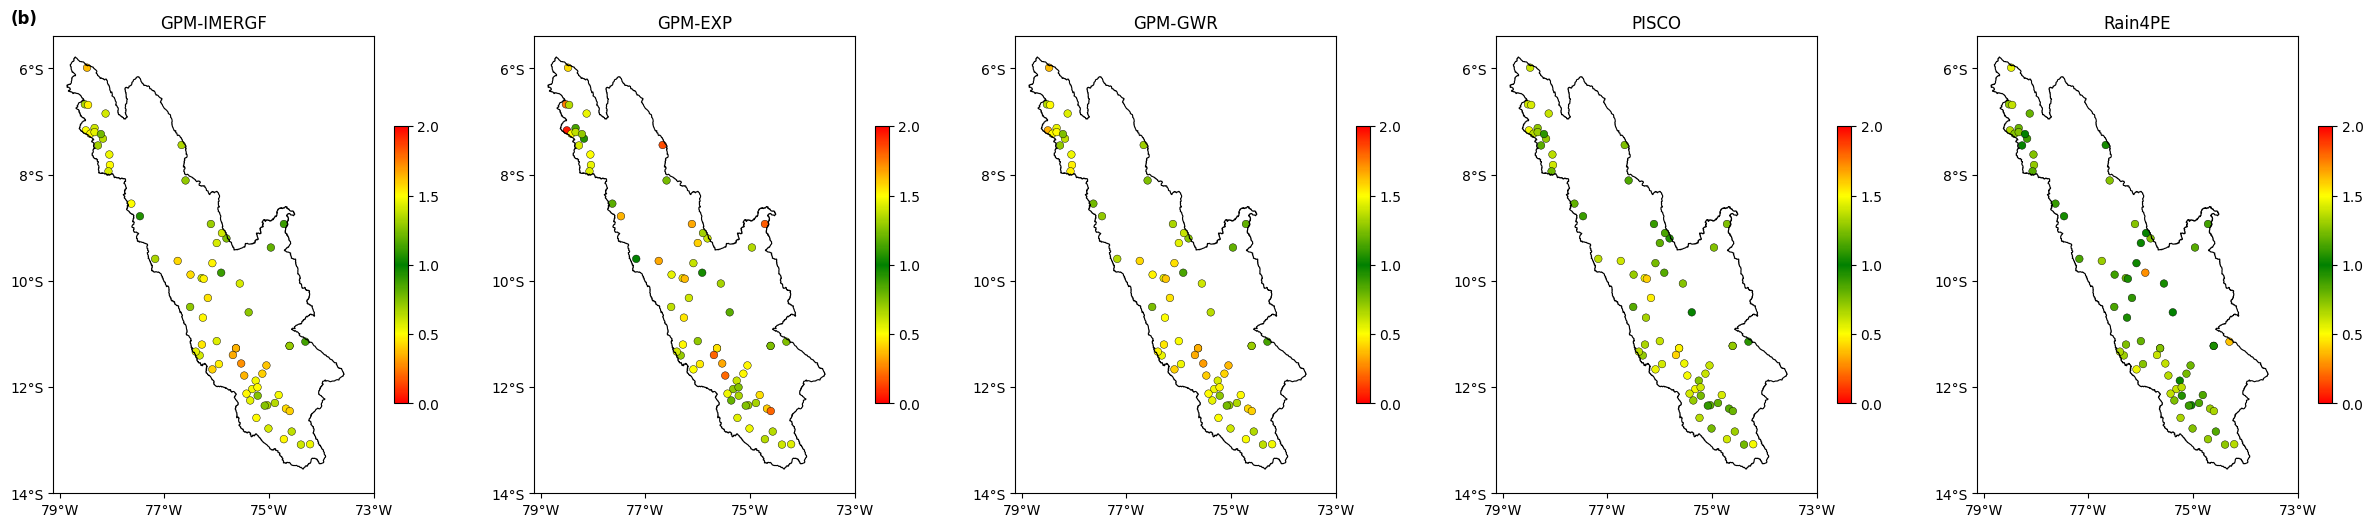

In [95]:
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

# Light green at center, yellow mid-way, red at extremes
cmap_fbi = LinearSegmentedColormap.from_list(
    'green-yellow-red',
    ['red', 'yellow', 'green', 'yellow', 'red']
)

# Center at 1
norm_fbi = TwoSlopeNorm(vmin=0, vcenter=1, vmax=2)


# Spatial plot for one statistic
area_study_shape = gpd.read_file('gis/study_area_shp/study_area.shp')
statistic = 'fbi'
datasets   = ['GPM-IMERGF', 'GPM-EXP','GPM-GWR', 'PISCO', 'Rain4PE']

fig, axs = plt.subplots(1, 5, figsize = (30,6), subplot_kw={'aspect': 'equal'})

axs = axs.ravel()


for i, ds in enumerate(datasets):
    ax = axs[i]
    if i == 0:
        ax.text(
        -0.05, 1.02, '(b)',
        transform=ax.transAxes,
        fontsize=12,
        fontweight='bold',
        va='bottom',
        ha='right'
        )
    df_ds = spatial_plot_dict[ds].to_crs(epsg=4326)  # Ensure CRS is WGS84 for plotting
    if statistic == 'pbias':
        # Convert to absolute values
        df_ds[statistic] = df_ds[statistic].abs()
    
    
    if statistic == 'fbi':
        df_ds.plot(
            column=statistic, ax=ax, legend=True,
            cmap=cmap_fbi, norm=norm_fbi,
            markersize=30, alpha=1.0, edgecolor='black', linewidth=0.3,
            legend_kwds={'shrink': 0.6, 'ticks': [0, 0.5, 1, 1.5, 2]}
        )
    else:
        df_ds.plot(
            column=statistic, ax=ax, legend=True, cmap='RdYlGn',
            markersize=30, alpha=1.0, edgecolor='black', linewidth=0.3,
            vmin=0, vmax=2, legend_kwds={'shrink': 0.6}
        )
    
    ax.set_title(f"{ds}")
    area_study_shape.to_crs(epsg=4326).plot(ax=ax, color='none', edgecolor='black', linewidth=0.8)

    # Set custom tick spacing
    xtick_step = 2  # longitude spacing
    ytick_step = 2  # latitude spacing
    
    xmin, xmax = -79, -73
    ymin, ymax = -14 , -5
    xticks = np.arange(np.floor(xmin), np.ceil(xmax) + 1, xtick_step)
    yticks = np.arange(np.floor(ymin), np.ceil(ymax) + 1, ytick_step)

    ax.set_xticks(xticks)
    ax.set_yticks(yticks)
    
    # Optional: add degree symbol formatting
    ax.set_xticklabels([f"{abs(x):.0f}°{'W' if x < 0 else 'E'}" for x in xticks])
    ax.set_yticklabels([f"{abs(y):.0f}°{'S' if y < 0 else 'N'}" for y in yticks])
    

    # ax.set_xlabel('Longitude')
    # ax.set_ylabel('Latitude')

In [ ]:
# Do comparison plot of statistic vs elevation per dataset
stats = ['csi', 'fbi', 'far', 'pod']
order_list = ["GPM-IMERGF","GPM-EXP","GPM-GWR","PISCO","Rain4PE"]

palette = sns.color_palette("Set1", n_colors=len(order_list))
color_map = dict(zip(order_list, palette))



fig, axs = plt.subplots(2, 2, figsize=(12, 12))

for i, stat in enumerate(stats):
    ax = axs[i // 2, i % 2]
    df_stat = df_dict[stat].copy()
    df_stat = df_stat.merge(station_df, on='Station', how='left')
    
    for ds in order_list:
        sub = df_stat[df_stat['Dataset'] == ds]
        ax.scatter(sub['Elevation'], sub['Statistic'], s=30, alpha=0.9, label=ds, color=color_map[ds])
    
    ax.set_xlabel('Elevation (m)')
    ax.set_ylabel(stat.upper())
    
fig.legend(order_list, loc="lower center", ncol=len(order_list), frameon=True)
plt.tight_layout(rect=[0, 0.05, 1, 1])

In [ ]:
# Do comparison plot of statistic vs elevation per dataset
stats = ['csi', 'fbi', 'far', 'pod']
order_list = ["GPM-IMERGF","GPM-EXP","GPM-GWR","PISCO","Rain4PE"]

palette = sns.color_palette("Set1", n_colors=len(order_list))
color_map = dict(zip(order_list, palette))



fig, axs = plt.subplots(2, 2, figsize=(12, 12))

for i, stat in enumerate(stats):
    ax = axs[i // 2, i % 2]
    df_stat = df_dict[stat].copy()
    df_stat = df_stat.merge(station_df, on='Station', how='left')
    
    for ds in order_list:
        sub = df_stat[df_stat['Dataset'] == ds]
        ax.scatter(sub['Slope'], sub['Statistic'], s=30, alpha=0.9, label=ds, color=color_map[ds])
    
    ax.set_xlabel('Slope (%)')
    ax.set_ylabel(stat.upper())
    
fig.legend(order_list, loc="lower center", ncol=len(order_list), frameon=True)
plt.tight_layout(rect=[0, 0.05, 1, 1])

In [ ]:
# Define dataset order and colors
order_list = ["GPM-IMERGF","GPM-EXP","GPM-GWR","PISCO","Rain4PE"]

palette = sns.color_palette("Set1", n_colors=len(order_list))
color_map = dict(zip(order_list, palette))

# Helper to pair two statistics by Dataset (+ Station if exists)
def prepare_pairs(df_x, df_y, name_x, name_y):
    if 'Station' in df_x.columns and 'Station' in df_y.columns:
        dx = df_x.rename(columns={'Statistic': name_x})[['Dataset','Station', name_x]]
        dy = df_y.rename(columns={'Statistic': name_y})[['Dataset','Station', name_y]]
        df = pd.merge(dx, dy, on=['Dataset','Station'], how='inner')
    else:
        dx = df_x.copy()
        dy = df_y.copy()
        dx['rid'] = dx.groupby('Dataset').cumcount()
        dy['rid'] = dy.groupby('Dataset').cumcount()
        dx = dx.rename(columns={'Statistic': name_x})[['Dataset','rid', name_x]]
        dy = dy.rename(columns={'Statistic': name_y})[['Dataset','rid', name_y]]
        df = pd.merge(dx, dy, on=['Dataset','rid'], how='inner').drop(columns='rid')
    return df

# Prepare the two comparison datasets
df_far_pod = prepare_pairs(df_far, df_pod, 'far', 'pod')
df_csi_fbi = prepare_pairs(df_acc, df_fbi, 'csi', 'fbi')

# Keep only datasets in the desired order
df_far_pod = df_far_pod[df_far_pod['Dataset'].isin(order_list)]
df_csi_fbi = df_csi_fbi[df_csi_fbi['Dataset'].isin(order_list)]

# --- Plot ---
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Left: FAR vs POD
ax = axs[0]
for ds in order_list:
    sub = df_far_pod[df_far_pod['Dataset'] == ds]
    ax.scatter(sub['far'], sub['pod'], s=30, alpha=0.9, label=ds, color=color_map[ds])

ax.set_xlabel("FAR")
ax.set_ylabel("POD")
ax.set_xlim(0, 0.6)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)
ax.text(0.90, 0.95, "(a)", transform=ax.transAxes,
        fontsize=12, fontweight='bold')

# Right: CSI vs FBI
ax = axs[1]
for ds in order_list:
    sub = df_csi_fbi[df_csi_fbi['Dataset'] == ds]
    ax.scatter(sub['csi'], sub['fbi'], s=30, alpha=0.9, label=ds, color=color_map[ds])

ax.set_xlabel("CSI")
ax.set_ylabel("FBI")
ax.set_xlim(0.3, 0.9)
ax.set_ylim(0, 1.75)
ax.grid(True, alpha=0.3)
ax.text(0.90, 0.95, "(b)", transform=ax.transAxes,
        fontsize=12, fontweight='bold')

# Legend once for both plots
fig.legend(order_list, loc="lower center", ncol=len(order_list), frameon=True)
plt.tight_layout(rect=[0, 0.05, 1, 1])


## Extreme Values

In [96]:
def get_extreme_index(stat_name):
    # Create a list to hold all the data
    all_stats = []
    # Define your datasets and their corresponding stats dictionaries
    dataset_stats = {
        'Local':        processed_data.extremeIndicesObserved,
        'GPM-IMERGF':   processed_data.extremeIndicesrawGPM,
        'GPM-GWR':      processed_data.extremeIndicesgwrGPM,
        'PISCO':        processed_data.extremeIndicesPISCO,
        'Rain4PE':      processed_data.extremeIndicesrain4pe,
        'GPM-EXP':      processed_data.extremeIndicesexpGPM
    }

    # Loop through each dataset and each station
    
    for dataset_name, stats_dict in dataset_stats.items():
        
        for station_name, stats_obj in stats_dict.items():
            # Get the desired stat from the stats object
            df = getattr(stats_obj[station_name],stat_name)


    # Convert to DataFrame
    df = pd.DataFrame(all_stats)

    return df

In [97]:
dataset_stats = {
    'Local':        processed_data.extremeIndicesObserved,
    'GPM-IMERGF':   processed_data.extremeIndicesrawGPM,
    'GPM-GWR':      processed_data.extremeIndicesgwrGPM,
    'PISCO':        processed_data.extremeIndicesPISCO,
    'Rain4PE':      processed_data.extremeIndicesrain4pe,
    'GPM-EXP':      processed_data.extremeIndicesexpGPM
}

extreme_dict = {}

for dataset_name, stats_dict in dataset_stats.items():    
    dataset_dict = {}
    for station_name, stats_obj in stats_dict.items():
        # Get the desired stat from the stats object
        dataset_dict[station_name] = {
            'cwd': getattr(stats_obj, 'cwd'),
            'cdd': getattr(stats_obj, 'cdd'),
            'r10': getattr(stats_obj, 'r10'),
            'r20': getattr(stats_obj, 'r20'),
            'r95p': getattr(stats_obj, 'r95p'),
            'r99p': getattr(stats_obj, 'r99p')}
    extreme_dict[dataset_name] = dataset_dict

In [183]:
records = []

for dataset, stations in extreme_dict.items():
    for station, indices in stations.items():
        for index_name, df in indices.items():
            mean_val = df.mean()  # adjust if col name differs
            lat = df.attrs.get('lat')      # or however you store coords
            lon = df.attrs.get('lon')
            records.append({
                'dataset': dataset,
                'station': station,
                'index': index_name,
                'mean_value': mean_val,
                'lat': lat,
                'lon': lon
            })

mean_df = pd.DataFrame(records)

In [184]:
# Spatial plot of extrme indices per dataset
extreme_indices = ['cwd', 'cdd', 'r10', 'r20', 'r95p', 'r99p']
datasets = ['GPM-IMERGF', 'GPM-GWR', 'PISCO', 'Rain4PE', 'GPM-EXP']

spatial_plot_dict = {}


gdf = stations_gdf.copy().rename(columns={'Station':'station'})  # start with stations (keeps geometry)

gdf = gdf.to_crs(epsg=4326)

mean_df = mean_df.merge(gdf[['station', 'geometry']], on='station', how='left')

mean_gdf = gpd.GeoDataFrame(mean_df, geometry='geometry', crs='EPSG:4326')


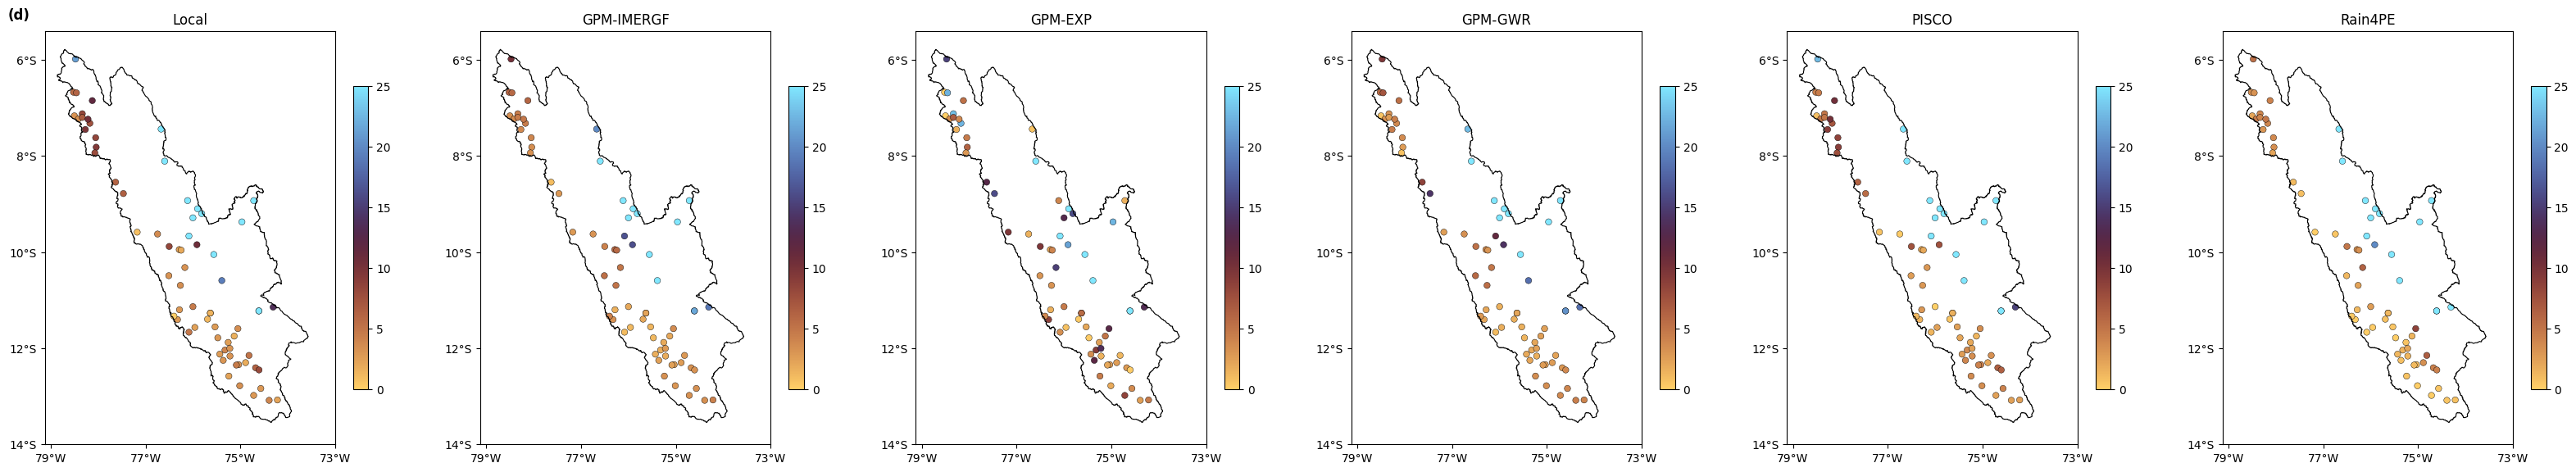

In [201]:
# Spatial plot for one statistic
area_study_shape = gpd.read_file('gis/study_area_shp/study_area.shp')
statistic = 'r20'
datasets   = ['Local','GPM-IMERGF', 'GPM-EXP','GPM-GWR', 'PISCO', 'Rain4PE']

fig, axs = plt.subplots(1, 6, figsize = (40,8), subplot_kw={'aspect': 'equal'})

axs = axs.ravel()


for i, ds in enumerate(datasets):
    ax = axs[i]
    if i == 0:
        ax.text(
        -0.05, 1.02, '(d)',
        transform=ax.transAxes,
        fontsize=12,
        fontweight='bold',
        va='bottom',
        ha='right'
        )

    
    plot_df = mean_gdf[(mean_gdf['dataset'] == ds) & (mean_gdf['index']==statistic)].copy()
    
    plot_df = plot_df.to_crs(epsg=4326)  # Ensure CRS is WGS84 for plotting
    
    plot_df.plot(column='mean_value', ax=ax, legend=True, cmap='managua', aspect=1,
               markersize=30,legend_kwds={'shrink':0.6}, alpha = 1.0,
              edgecolor='black', linewidth=0.3, vmin = 0, vmax = 25)
    
    ax.set_title(f"{ds}")
    area_study_shape.to_crs(epsg=4326).plot(ax=ax, color='none', edgecolor='black', linewidth=0.8)

    # Set custom tick spacing
    xtick_step = 2  # longitude spacing
    ytick_step = 2  # latitude spacing
    
    xmin, xmax = -79, -73
    ymin, ymax = -14 , -5
    xticks = np.arange(np.floor(xmin), np.ceil(xmax) + 1, xtick_step)
    yticks = np.arange(np.floor(ymin), np.ceil(ymax) + 1, ytick_step)

    ax.set_xticks(xticks)
    ax.set_yticks(yticks)
    
    # Optional: add degree symbol formatting
    ax.set_xticklabels([f"{abs(x):.0f}°{'W' if x < 0 else 'E'}" for x in xticks])
    ax.set_yticklabels([f"{abs(y):.0f}°{'S' if y < 0 else 'N'}" for y in yticks])